# Approximating Intrinsic Volumes

## Setup

In [1]:
import flagqmcpy 
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.spatial
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Kernel Setup

In [2]:
N = 5
p = 3
assert N>p
lam = torch.tensor([max(p+1-i,1) for i in range(N)],device=DEVICE,dtype=float)
_,_inv_m,m = lam.unique(return_inverse=True,return_counts=True)
assert (_inv_m[:-1]>=_inv_m[1:]).all()
d = 1/2*(N**2-(m**2).sum())
print("lam = %s"%str(lam))
print("N = %d"%N)
print("m = %s"%str(m))
print("d = %d"%d)
kernels = {nu: flagqmcpy.KernelMaternChordal(lam,nu) for nu in flagqmcpy.KernelMaternChordal.SUPPORTED_NU}
print("flagqmcpy.KernelMaternChordal.SUPPORTED_NU = %s"%flagqmcpy.KernelMaternChordal.SUPPORTED_NU)
if True: # cube [-1,1]^N
    Z = torch.tensor([[2*int(b)-1 for b in np.binary_repr(k,width=N)] for k in range(2**N)],dtype=float,device=DEVICE)
    Vk_true = (agsutil.comb(torch.tensor(N,device=DEVICE),torch.arange(N+1,device=DEVICE))*2**torch.arange(N+1,device=DEVICE))[:(1+p)]
elif True: # convex hull of random normal points
    Z = torch.randn(10,N,device=DEVICE)
    Vk_true = torch.nan*torch.ones(N+1,device=DEVICE)
else:
    raise Exception("please set one of the above cases to true ")
print("Z.shape = %s"%str(tuple(Z.shape)))
print("Z = \n%s"%str(Z))
print("Vk_true = %s"%Vk_true)
Nvec = torch.arange(N+1,device=DEVICE)
logkappa = (Nvec/2)*np.log(np.pi)-torch.lgamma(Nvec/2+1)
print("logkappa.shape = %s"%str(tuple(logkappa.shape)))
print("kappa = torch.exp(logkappa) = %s"%torch.exp(logkappa))
coeff_Vk = torch.exp(agsutil.logcomb(Nvec[-1],Nvec)+logkappa[-1]-logkappa-torch.flip(logkappa,dims=(0,)))
print("coeff_Vk.shape = %s"%str(tuple(coeff_Vk.shape)))
print("coeff_Vk = %s"%coeff_Vk)

lam = tensor([4., 3., 2., 1., 1.])
N = 5
m = tensor([2, 1, 1, 1])
d = 9
flagqmcpy.KernelMaternChordal.SUPPORTED_NU = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, inf]
Z.shape = (32, 5)
Z = 
tensor([[-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1.,  1.],
        [-1., -1., -1.,  1., -1.],
        [-1., -1., -1.,  1.,  1.],
        [-1., -1.,  1., -1., -1.],
        [-1., -1.,  1., -1.,  1.],
        [-1., -1.,  1.,  1., -1.],
        [-1., -1.,  1.,  1.,  1.],
        [-1.,  1., -1., -1., -1.],
        [-1.,  1., -1., -1.,  1.],
        [-1.,  1., -1.,  1., -1.],
        [-1.,  1., -1.,  1.,  1.],
        [-1.,  1.,  1., -1., -1.],
        [-1.,  1.,  1., -1.,  1.],
        [-1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.],
        [ 1., -1., -1., -1., -1.],
        [ 1., -1., -1., -1.,  1.],
        [ 1., -1., -1.,  1., -1.],
        [ 1., -1., -1.,  1.,  1.],
        [ 1., -1.,  1., -1., -1.],
        [ 1., -1.,  1., -1.,  1.],
        [ 1., -1.,  1.,  1., -1.],
        [ 1., 

## Transform and Generators

In [3]:
def opt_weights(x, eps=1e-12):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat+eps*torch.eye(kmat.size(-1),device=DEVICE),upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w/w.sum(-1,keepdim=True)
def genflag_qr_iid_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_qr_iid(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w
def genflag_qr_ld_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_qr_ld(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w
def genflag_eig_iid_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_eig_iid(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w
def genflag_eig_ld_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_eig_ld(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w

In [4]:
def approx_intrinsic_volumes(q, w):
    n = w.size(0)
    vols = torch.ones((1+p,n),device=DEVICE)
    for k in range(1,p+1):
        Zk = torch.einsum("lj,ijk->ilk",Z,q[...,:k])
        if k==1:
            vols[k,:] = Zk[...,0].amax(1)-Zk[...,0].amin(1)
            continue
        for i in range(n):
            vols[k,i] = scipy.spatial.ConvexHull(Zk[i].cpu().numpy()).volume
    Vi_hat = coeff_Vk[:(1+p)]*(vols*w).sum(-1)
    return Vi_hat
print("Vi_hat = %s"%approx_intrinsic_volumes(*flagqmcpy.genflag_q_eig_iid_equal_w(n=2**10,N=N,seed=7,device=DEVICE)))

Vi_hat = tensor([ 1.0000,  9.9562, 39.9179, 79.6966])


In [5]:
genf_funcs = [
    [r"QR IID $x$ ~ Equal $w$", flagqmcpy.genflag_q_qr_iid_equal_w], 
    [r"QR LD $x$ ~ Equal $w$", flagqmcpy.genflag_q_qr_ld_equal_w], 
    [r"QR IID $x$ ~ Opt $w$", genflag_qr_iid_q_opt_w], 
    [r"QR LD $x$ ~ Opt $w$", genflag_qr_ld_q_opt_w], 
    [r"Eig IID $x$ ~ Equal $w$", flagqmcpy.genflag_q_eig_iid_equal_w], 
    [r"Eig LD $x$ ~ Equal $w$", flagqmcpy.genflag_q_eig_ld_equal_w], 
    [r"Eig IID $x$ ~ Opt $w$", genflag_eig_iid_q_opt_w], 
    [r"Eig LD $x$ ~ Opt $w$", genflag_eig_ld_q_opt_w], 
    
]
nu = np.inf
s = nu+d/2
kernel = kernels[nu]
n = 2**torch.arange(12)
trials = 5
seeds = [i for i in range(trials)]
Vk_hats = torch.nan*torch.empty((len(genf_funcs),len(n),trials,1+p))
errors = torch.nan*torch.empty((len(genf_funcs),len(n),trials,1+p))
t0 = time.perf_counter()
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            q,w = genf_func(n=n[j],N=N,seed=seeds[t],device=DEVICE)
            Vk_hats[i,j,t,:] = approx_intrinsic_volumes(q=q,w=w)
            errors[i,j,t,:] = torch.abs(Vk_hats[i,j,t,:]-Vk_true)
            with np.printoptions(formatter={"float":lambda x: "%.1e"%x}):
                print("        trial %-10d time %-10.1f Vk_hat = %-40s error = %s"%(t,time.perf_counter()-t0,Vk_hats[i,j,t,:].cpu().numpy(),errors[i,j,t,:] .cpu().numpy()))

QR IID $x$ ~ Equal $w$
    n = 1
        trial 0          time 0.0        Vk_hat = [1.0e+00 9.1e+00 4.0e+01 8.2e+01]        error = [0.0e+00 9.1e-01 3.8e-01 1.6e+00]
        trial 1          time 0.0        Vk_hat = [1.0e+00 1.1e+01 3.7e+01 8.4e+01]        error = [0.0e+00 6.5e-01 2.5e+00 3.6e+00]
        trial 2          time 0.0        Vk_hat = [1.0e+00 9.8e+00 4.8e+01 9.0e+01]        error = [0.0e+00 2.5e-01 7.5e+00 1.0e+01]
        trial 3          time 0.0        Vk_hat = [1.0e+00 1.0e+01 4.2e+01 9.2e+01]        error = [0.0e+00 1.8e-01 1.9e+00 1.2e+01]
        trial 4          time 0.0        Vk_hat = [1.0e+00 9.6e+00 4.1e+01 7.1e+01]        error = [0.0e+00 4.4e-01 6.6e-01 9.1e+00]
    n = 2
        trial 0          time 0.0        Vk_hat = [1.0e+00 9.2e+00 3.9e+01 8.3e+01]        error = [0.0e+00 7.5e-01 1.2e+00 3.3e+00]
        trial 1          time 0.0        Vk_hat = [1.0e+00 1.1e+01 3.6e+01 7.5e+01]        error = [0.0e+00 8.5e-01 3.8e+00 5.4e+00]
        trial 2          t

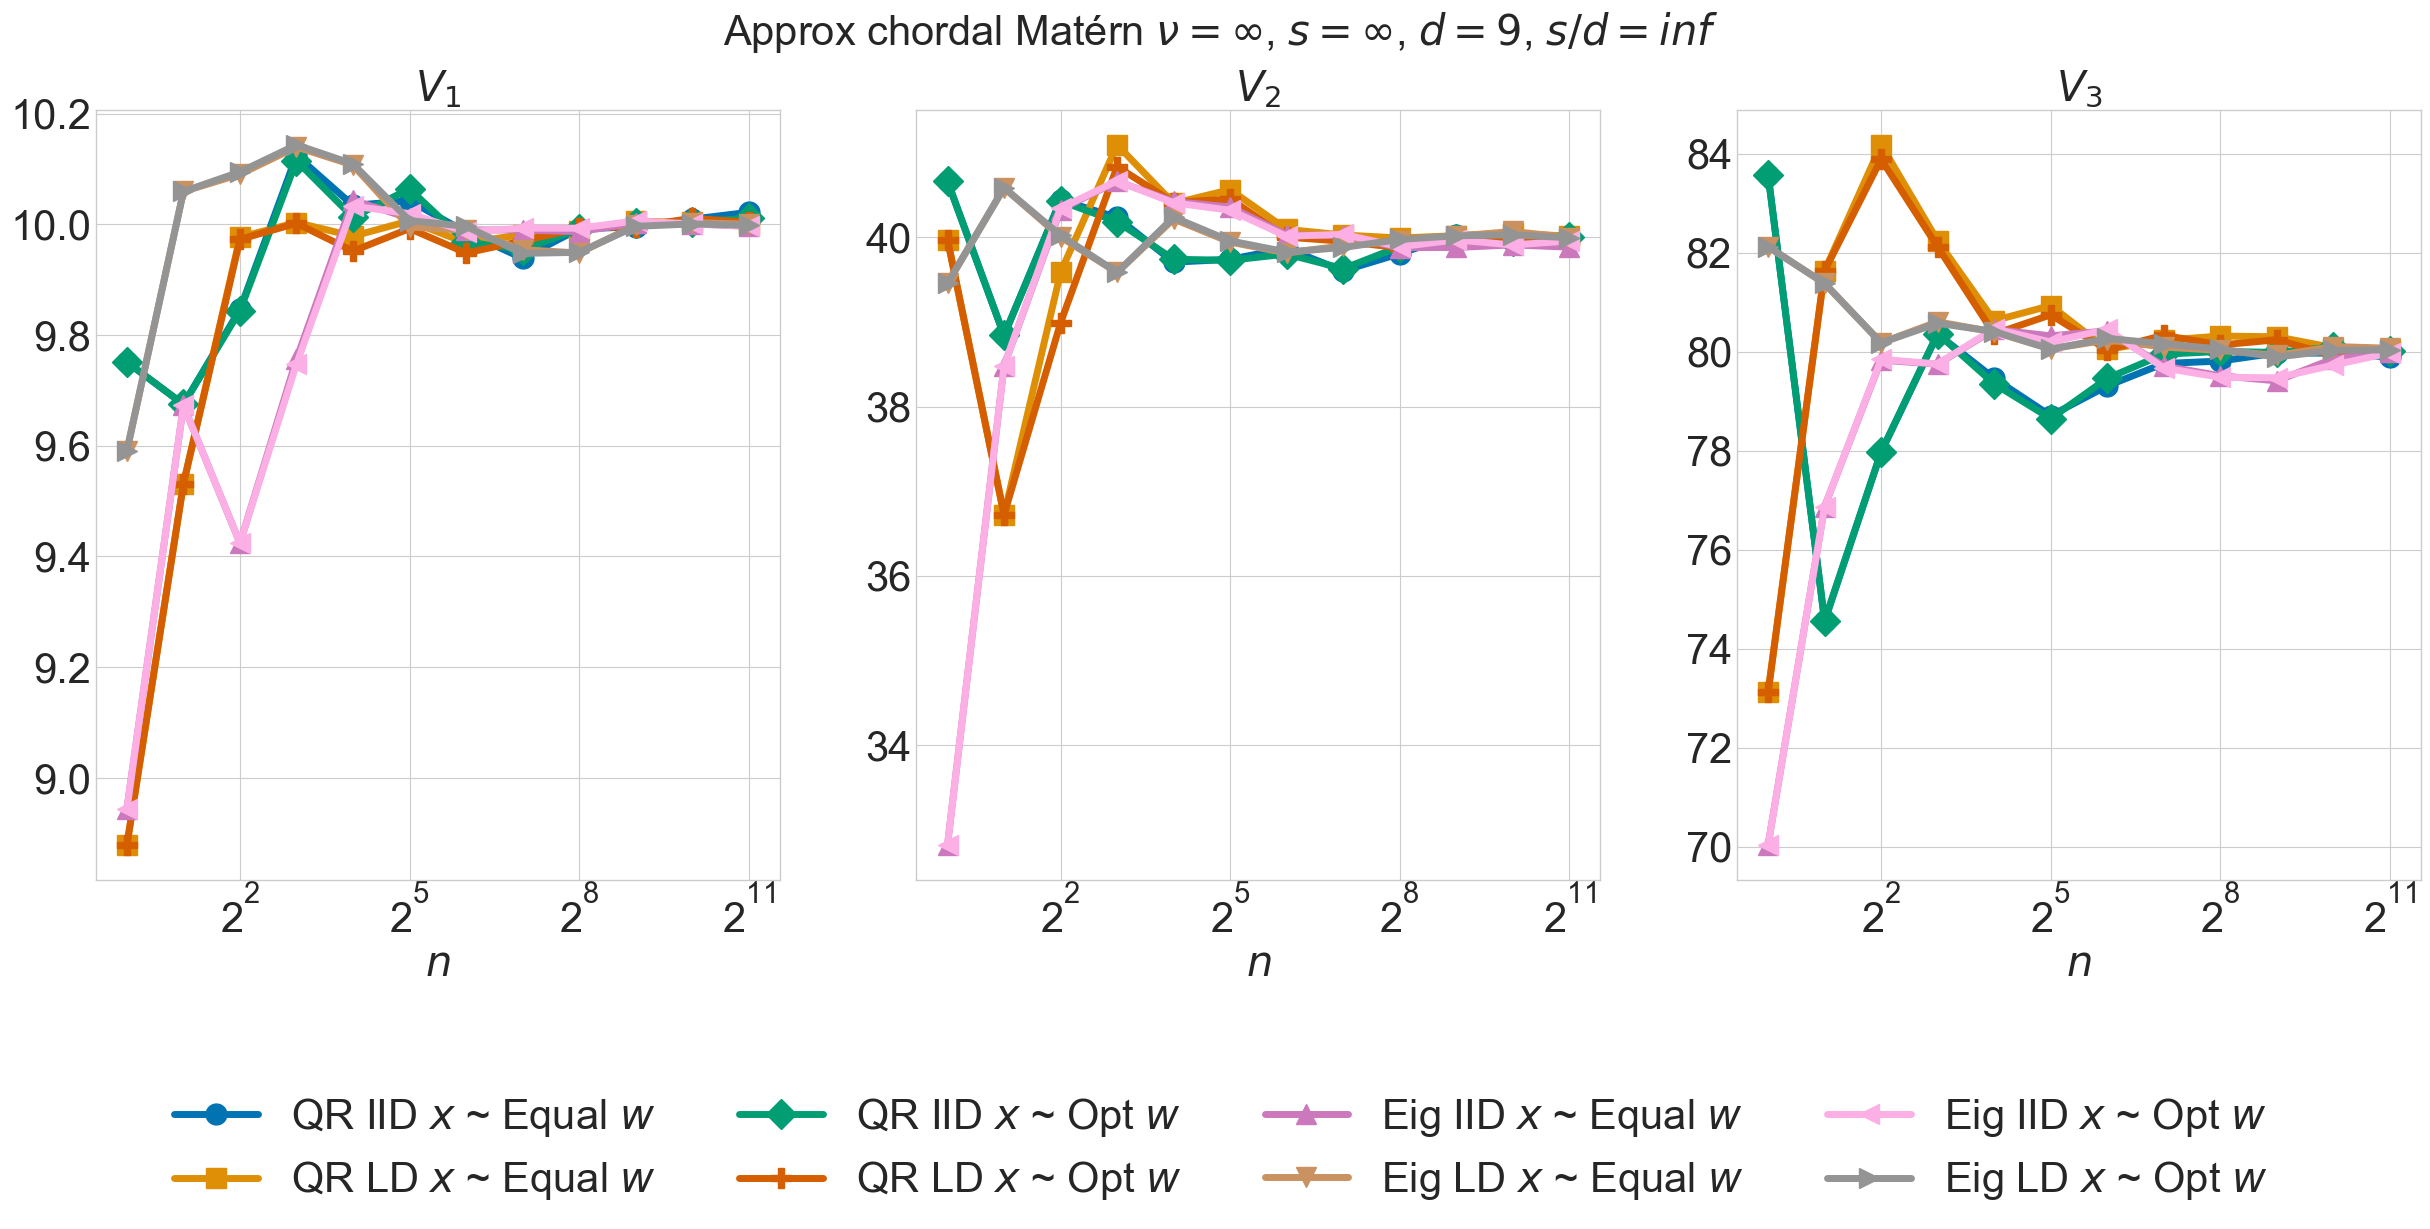

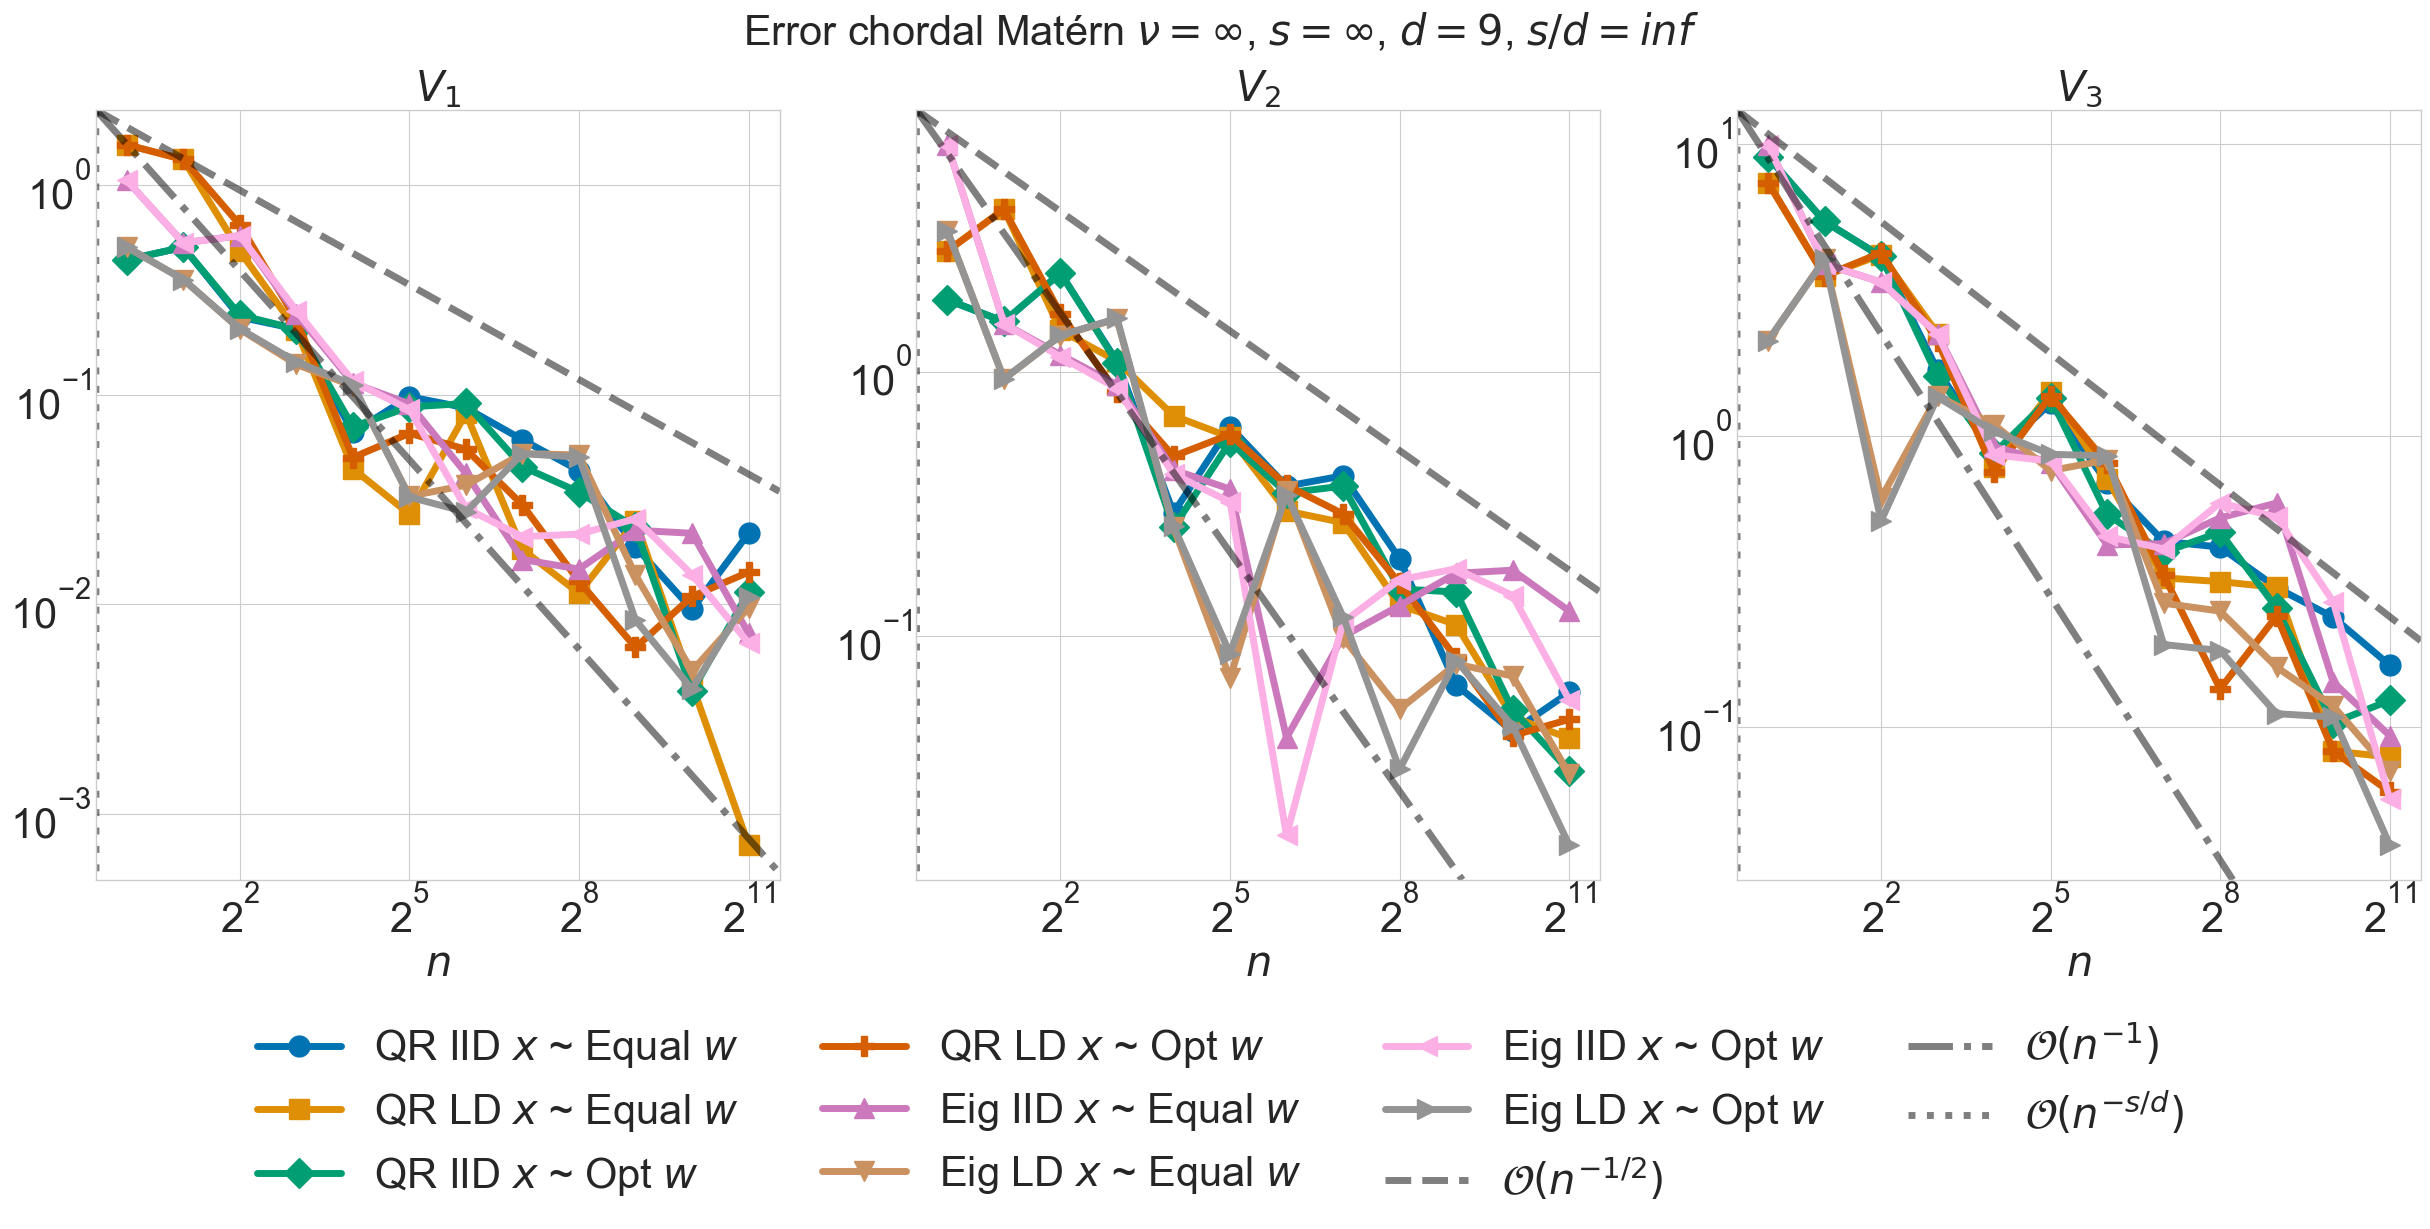

In [13]:
for l,(metric,metric_name) in enumerate(zip(
    [Vk_hats.median(-2).values,errors.median(-2).values],
    ["Approx","Error"])):
    fig,ax = pyplot.subplots(nrows=1,ncols=p,figsize=(MPLP["PW"],MPLP["PW"]/p),sharex=True,sharey=False)
    for k in range(1,p+1):
        for i,(key,_) in enumerate(genf_funcs):
            ax[k-1].plot(n,metric[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key if k==1 else None)
        ax[k-1].set_xscale("log",base=2)
        if l==1: ax[k-1].set_yscale("log",base=10)
    for k in range(1,p+1):
        ax[k-1].set_xlabel(r"$n$")
        ax[k-1].set_title(r"$V_{%d}$"%k)
        if l==1:
            xmin,xmax = ax[k-1].get_xlim()
            ymin,ymax = ax[k-1].get_ylim()
            ax[k-1].set_xlim([xmin,xmax])
            ax[k-1].set_ylim([ymin,ymax])
            ax[k-1].axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,linestyle="dashed",label=r"$\mathcal{O}(n^{-1/2})$" if k==1 else None)
            ax[k-1].axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,linestyle="dashdot",label=r"$\mathcal{O}(n^{-1})$" if k==1 else None)
            ax[k-1].axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,linestyle="dotted",label=r"$\mathcal{O}(n^{-s/d})$" if k==1 else None)
    fig.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.25))
    assert s==np.inf or s%1 in [0,1/2]
    if s==np.inf:
        s_str = r"\infty"
    elif s%1==0:
        s_str = r"%d"%s 
    elif s%1==1/2:
        s_str = r"$%d/2$"%(2*s)
    fig.suptitle(r"%s chordal Matérn "%metric_name+kernel.nu_str+r", $s = %s$"%s_str+r", $d=%d$"%d+r", $s/d = %.2f$"%(s/d));

In [ ]:
for k in range(1,p+1):
    Vk_hats_df_k = pd.DataFrame(Vk_hats[...,k].median(-1).values.T,columns=[name for (name,_) in genf_funcs])
    Vk_hats_df_k['n'] = n
    Vk_hats_df_k = Vk_hats_df_k.set_index('n')
    print(r"Vk_hats for k=%d with true value %.5e"%(k,Vk_true[k]))
    display(Vk_hats_df_k);

Vk_hats for k=1 with true value 1.00000e+01


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$
n,,,,,,,,
1,9.751151,8.879028,9.751151,8.879028,8.944478,9.591342,8.944478,9.591342
2,9.674933,9.531325,9.674933,9.531325,9.672979,10.059470,9.672979,10.059470
4,9.846533,9.977122,9.840713,9.964457,9.424149,10.090615,9.423150,10.096675
8,10.124537,10.003328,10.113531,10.000095,9.756657,10.139837,9.750825,10.146468
16,10.034323,9.978710,10.012528,9.965722,10.043830,10.107069,10.025146,10.108482
32,10.042850,10.006344,10.074327,9.992845,10.010935,9.995196,10.021612,10.010119
64,9.985831,9.966454,9.970971,9.950143,9.989992,9.989575,9.978729,9.997049
128,9.938870,9.981689,9.953349,9.971412,9.989897,9.954268,9.995123,9.948503
256,9.992020,9.988682,9.991356,9.993560,9.986931,9.948278,9.994517,9.951183


Vk_hats for k=2 with true value 4.00000e+01


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$
n,,,,,,,,
1,40.662848,39.975850,40.662848,39.975850,32.819839,39.457923,32.819839,39.457923
2,38.842238,36.720850,38.842238,36.720850,38.482029,40.587026,38.482029,40.587026
4,40.443743,39.586840,40.420134,39.137458,40.329623,40.005225,40.345892,40.030208
8,40.236713,41.095011,40.183468,40.896664,40.663529,39.586274,40.685509,39.583784
16,39.707841,40.402825,39.767886,40.399999,40.425327,40.217954,40.425468,40.254995
32,39.741582,40.565145,39.734643,40.453809,40.359573,39.945337,40.311273,39.951897
64,39.870931,40.095513,39.767881,40.016606,40.031709,39.816168,40.017951,39.816582
128,39.605414,40.029069,39.645952,39.957623,40.022602,39.901362,40.028761,39.871883
256,39.808074,39.993379,39.911333,39.893483,39.879578,39.954844,39.896746,39.979511


Vk_hats for k=3 with true value 8.00000e+01


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$
n,,,,,,,,
1,83.569714,73.121857,83.569714,73.121857,70.034794,82.122196,70.034794,82.122196
2,74.558656,81.637705,74.558656,81.637705,76.872064,81.380261,76.872064,81.380261
4,77.973341,84.181126,77.987717,83.925146,79.831109,80.180500,79.842023,80.184168
8,80.356276,82.241327,80.350321,82.101137,79.746899,80.604649,79.713335,80.572851
16,79.461479,80.628342,79.335900,80.404424,80.450677,80.398553,80.475780,80.409999
32,78.706031,80.933085,78.658351,80.849471,80.320937,80.056775,80.161667,80.017150
64,79.307955,80.048115,79.429149,79.986266,80.422449,80.238113,80.488590,80.249517
128,79.762295,80.232622,79.875793,80.306111,79.711874,80.094635,79.710496,80.147378
256,79.811343,80.316480,79.968413,80.114390,79.514997,80.025530,79.495699,80.070635


In [ ]:
for k in range(1,p+1):
    errors_df_k = pd.DataFrame(errors[...,k].median(-1).values.T,columns=[name for (name,_) in genf_funcs])
    errors_df_k['n'] = n
    errors_df_k = errors_df_k.set_index('n')
    print(r"errors for k=%d"%k)
    display(errors_df_k);

errors for k=1


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$
n,,,,,,,,
1,0.441713,1.561636,0.441713,1.561636,1.055522,0.507437,1.055522,0.507437
2,0.506759,1.329554,0.506759,1.329554,0.531903,0.355325,0.531903,0.355325
4,0.235205,0.485177,0.245976,0.607395,0.575851,0.205820,0.576850,0.207553
8,0.206342,0.204113,0.203863,0.210049,0.243343,0.139837,0.249175,0.146468
16,0.066282,0.044494,0.072771,0.050384,0.114014,0.110494,0.119706,0.112291
32,0.098058,0.026996,0.087729,0.058427,0.090722,0.032853,0.083780,0.029936
64,0.086835,0.081667,0.085243,0.049857,0.042231,0.037097,0.023295,0.026690
128,0.061130,0.018311,0.046651,0.028588,0.016392,0.052481,0.017624,0.052707
256,0.043567,0.011318,0.036050,0.009871,0.014760,0.051722,0.024088,0.048817


errors for k=2


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$
n,,,,,,,,
1,1.862972,2.854552,1.862972,2.854552,7.180161,3.388706,7.180161,3.388706
2,1.544869,4.098479,1.544869,4.098479,1.517971,0.936833,1.517971,0.936833
4,2.352102,1.430863,2.362091,1.623454,1.156436,1.365944,1.111455,1.378781
8,1.091386,1.095011,1.081764,0.896664,0.891469,1.580265,0.826021,1.586164
16,0.292159,0.680629,0.232114,0.464937,0.425327,0.257873,0.425468,0.260662
32,0.618347,0.565145,0.531774,0.627351,0.359573,0.069359,0.311273,0.087734
64,0.368954,0.297351,0.361384,0.364702,0.041362,0.352488,0.017951,0.348314
128,0.403804,0.268677,0.354048,0.297110,0.099815,0.098638,0.110160,0.128117
256,0.196133,0.131026,0.143983,0.140017,0.130577,0.053019,0.169632,0.046760


errors for k=3


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$
n,,,,,,,,
1,9.056942,7.395969,9.056942,7.395969,9.965206,2.122196,9.965206,2.122196
2,5.441344,3.539100,5.441344,3.539100,3.888409,4.031588,3.888409,4.031588
4,4.130535,4.181126,4.122302,4.237742,3.367789,0.611328,3.416591,0.482069
8,1.679797,2.241327,1.579048,2.101137,2.236416,1.372186,2.229618,1.308176
16,0.857865,0.782590,0.926038,0.715724,0.919658,1.092804,0.793054,0.997759
32,1.293969,1.420449,1.341649,1.426485,0.810400,0.760110,0.864826,0.867906
64,0.692045,0.712635,0.570851,0.892766,0.422449,0.827890,0.488590,0.843197
128,0.435032,0.326015,0.376552,0.306111,0.427133,0.266858,0.388111,0.190559
256,0.415578,0.316480,0.496719,0.114390,0.523630,0.250654,0.557898,0.181226
